# CC3182 – Visión por Computadora  
## Examen Corto 1 – Task 3 (Implementación)

**Integrantes:**  
- Andy Fuentes — 22944  
- Diederich Solís — 22952  

**Profesor:** Luis Alberto Suriano Saravia  
**Fecha:** 05/03/2026  



### Dataset
**Mango Leaf Disease Dataset (Kaggle)**

### Objetivo
Entrenar un modelo de clasificación multiclase con **Transfer Learning** (VGG-16 o AlexNet) para detectar enfermedades en hojas de mango, reportando:
- **Accuracy**
- **Matriz de confusión**
- Conclusión breve sobre **overfitting** y el rol de **Dropout**

# 1) Imports y Configuración

In [22]:
import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2) Pipeline de datos


In [23]:
!pip -q install kagglehub

In [24]:
import kagglehub

path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print("Path base:", path)
print("Contenido base:", os.listdir(path)[:30])

Using Colab cache for faster access to the 'mango-leaf-disease-dataset' dataset.
Path base: /kaggle/input/mango-leaf-disease-dataset
Contenido base: ['Powdery Mildew', 'Cutting Weevil', 'Anthracnose', 'Bacterial Canker', 'Sooty Mould', 'Gall Midge', 'Healthy', 'Die Back']


In [25]:
import os
from pathlib import Path

def find_imagefolder_root(base_path: str):
    base = Path(base_path)
    candidates = [base] + list(base.rglob("*"))

    exts = {".jpg", ".jpeg", ".png", ".webp"}

    for d in candidates:
        if not d.is_dir():
            continue

        subdirs = [x for x in d.iterdir() if x.is_dir()]
        if not subdirs:
            continue

        for sd in subdirs:
            imgs = [p for p in sd.iterdir() if p.is_file() and p.suffix.lower() in exts]
            if len(imgs) > 0:
                return str(d)

    return None

DATA_DIR = find_imagefolder_root(path)
print("DATA_DIR detectado:", DATA_DIR)
print("Clases (primeras):", os.listdir(DATA_DIR)[:20])

DATA_DIR detectado: /kaggle/input/mango-leaf-disease-dataset
Clases (primeras): ['Powdery Mildew', 'Cutting Weevil', 'Anthracnose', 'Bacterial Canker', 'Sooty Mould', 'Gall Midge', 'Healthy', 'Die Back']


In [26]:
# Normalización ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

img_size = 224

train_tfms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tfms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [27]:
dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_tfms)

class_names = dataset.classes
num_classes = len(class_names)

print("Número de clases:", num_classes)
print("Clases:", class_names)
print("Total imágenes:", len(dataset))

Número de clases: 8
Clases: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Total imágenes: 4000


In [28]:
train_ratio = 0.8
train_len = int(len(dataset) * train_ratio)
val_len = len(dataset) - train_len

train_ds, val_ds = random_split(dataset, [train_len, val_len])

val_ds.dataset.transform = val_tfms

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

len(train_ds), len(val_ds)

(3200, 800)

## 3) Adaptación de arquitectura (VGG-16 preentrenada, freeze y nuevo clasificador)

In [29]:
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [30]:
# Freeze extractor de características (convs)
for p in model.features.parameters():
    p.requires_grad = False

In [31]:
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)

model = model.to(device)
model.classifier[-1]

Linear(in_features=4096, out_features=8, bias=True)

## 4) Entrenamiento (CrossEntropyLoss y Adam)

In [32]:
criterion = nn.CrossEntropyLoss()

params_to_train = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_train, lr=1e-3)

epochs = 8

In [33]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [34]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return running_loss / total, correct / total, all_labels, all_preds

In [35]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}")

Epoch 01/8 | Train Loss: 0.5901 Acc: 0.8891 | Val Loss: 0.5496 Acc: 0.9375
Epoch 02/8 | Train Loss: 0.6189 Acc: 0.9566 | Val Loss: 0.3633 Acc: 0.9725
Epoch 03/8 | Train Loss: 0.5001 Acc: 0.9747 | Val Loss: 0.4286 Acc: 0.9838
Epoch 04/8 | Train Loss: 0.3621 Acc: 0.9847 | Val Loss: 0.7582 Acc: 0.9725
Epoch 05/8 | Train Loss: 0.7623 Acc: 0.9794 | Val Loss: 0.2534 Acc: 0.9925
Epoch 06/8 | Train Loss: 0.6530 Acc: 0.9878 | Val Loss: 1.4601 Acc: 0.9775
Epoch 07/8 | Train Loss: 1.0093 Acc: 0.9841 | Val Loss: 1.2182 Acc: 0.9850
Epoch 08/8 | Train Loss: 0.6828 Acc: 0.9897 | Val Loss: 0.4693 Acc: 0.9900


## 5) Evaluación(Accuracy, Matriz de confusión)

In [36]:
val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)
print("Accuracy (validación):", val_acc)

Accuracy (validación): 0.99


In [37]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[100,   0,   0,   1,   0,   0,   0,   1],
       [  0, 118,   0,   0,   0,   0,   0,   0],
       [  0,   0,  96,   0,   0,   0,   0,   0],
       [  0,   0,   0,  92,   0,   0,   0,   0],
       [  0,   0,   0,   0,  93,   0,   0,   3],
       [  0,   0,   0,   0,   0,  96,   0,   0],
       [  0,   0,   0,   0,   0,   0,  86,   3],
       [  0,   0,   0,   0,   0,   0,   0, 111]])

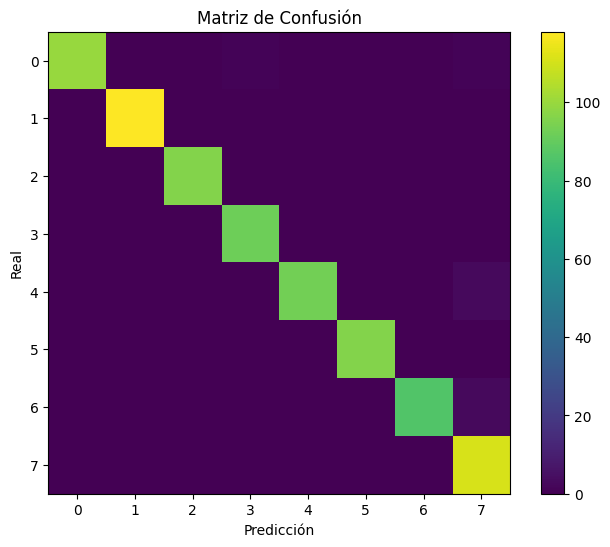

In [38]:
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.show()

In [39]:
print(classification_report(y_true, y_pred, target_names=class_names))

                  precision    recall  f1-score   support

     Anthracnose       1.00      0.98      0.99       102
Bacterial Canker       1.00      1.00      1.00       118
  Cutting Weevil       1.00      1.00      1.00        96
        Die Back       0.99      1.00      0.99        92
      Gall Midge       1.00      0.97      0.98        96
         Healthy       1.00      1.00      1.00        96
  Powdery Mildew       1.00      0.97      0.98        89
     Sooty Mould       0.94      1.00      0.97       111

        accuracy                           0.99       800
       macro avg       0.99      0.99      0.99       800
    weighted avg       0.99      0.99      0.99       800



## 6) Curvas de entrenamiento

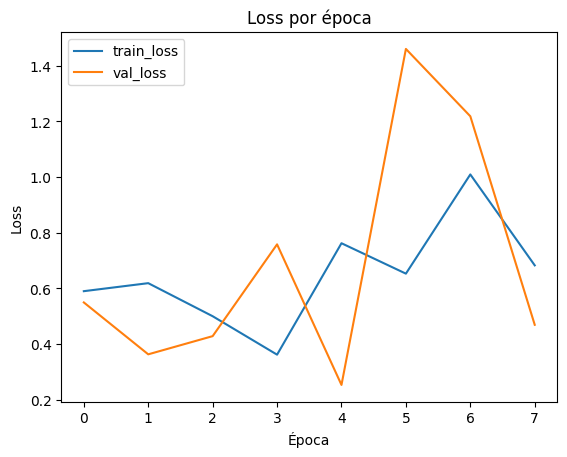

In [40]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

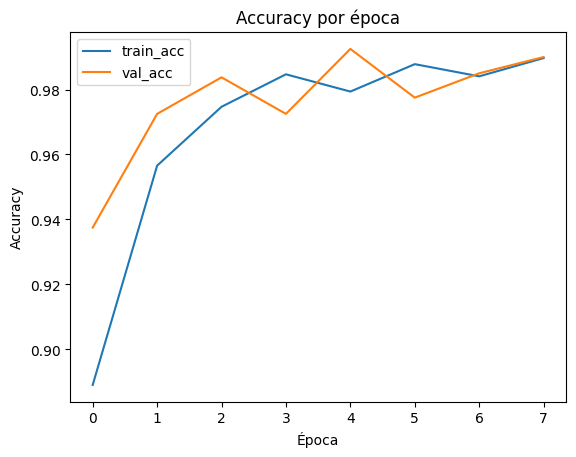

In [41]:
plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Informe y conclusiones

Después de entrenar el modelo utilizando transfer learning con VGG-16, se evaluó su desempeño utilizando el conjunto de validación, es decir, imágenes que el modelo no había visto durante el entrenamiento. La precisión global obtenida fue cercana al **99%**, lo cual indica que el modelo logró identificar correctamente la gran mayoría de hojas de mango en sus respectivas categorías.

La matriz de confusión permite observar cómo se distribuyen las predicciones del modelo entre las distintas clases. En general, la mayor parte de las predicciones se encuentran en la diagonal principal, lo cual significa que el modelo clasificó correctamente la mayoría de imágenes. Algunas pequeñas confusiones entre clases pueden ocurrir, especialmente entre enfermedades que tienen patrones visuales similares en las hojas, lo cual es algo esperado en este tipo de problema.

Al analizar las gráficas de entrenamiento, tanto la accuracy de entrenamiento como la de validación alcanzan valores muy similares y se mantienen bastante cercanas durante las épocas. Esto sugiere que el modelo no está simplemente memorizando los datos de entrenamiento, sino que también es capaz de generalizar a datos que no ha visto antes.

En cuanto a la función de pérdida (loss), se observan algunas variaciones en la pérdida de validación en ciertas épocas, lo cual es normal cuando el dataset tiene variabilidad o no es extremadamente grande. Sin embargo, no se observa un incremento sostenido de la pérdida de validación mientras la pérdida de entrenamiento continúa disminuyendo, por lo que no hay evidencia clara de un sobreajuste fuerte en este experimento.

Finalmente, en caso de que en futuros entrenamientos apareciera overfitting, una técnica común para reducirlo es **Dropout**, la cual consiste en desactivar aleatoriamente algunas neuronas durante el entrenamiento. Esto evita que la red dependa demasiado de ciertas conexiones específicas y ayuda a que el modelo aprenda representaciones más generales.